In [226]:
import numpy as np
import matplotlib.pyplot as plt

Определим входные переменные и саму модель

In [ ]:
N = 50 # диплоиды (представители)
p0 = 0.2 # частота аллея 
T = 200 # число поколений
R = 30 # число репликаций

In [228]:
def wright_fisher(N, p0, T):
    p = np.zeros(T + 1)
    p[0] = p0
    for t in range(T):
        alley_count = 2 * N
        X_t_1 = np.random.binomial(alley_count, p[t])
        p[t + 1] = X_t_1 / alley_count
    return p


def run_simulation_wright_fisher(N, p0, T, R):
    gen = []
    for r in range(R):
        gen.append(wright_fisher(N, p0, T))
    return np.array(gen)

In [229]:
simulation_generations = run_simulation_wright_fisher(N, p0, T, R)

## 1. Траектории частот $p_t$

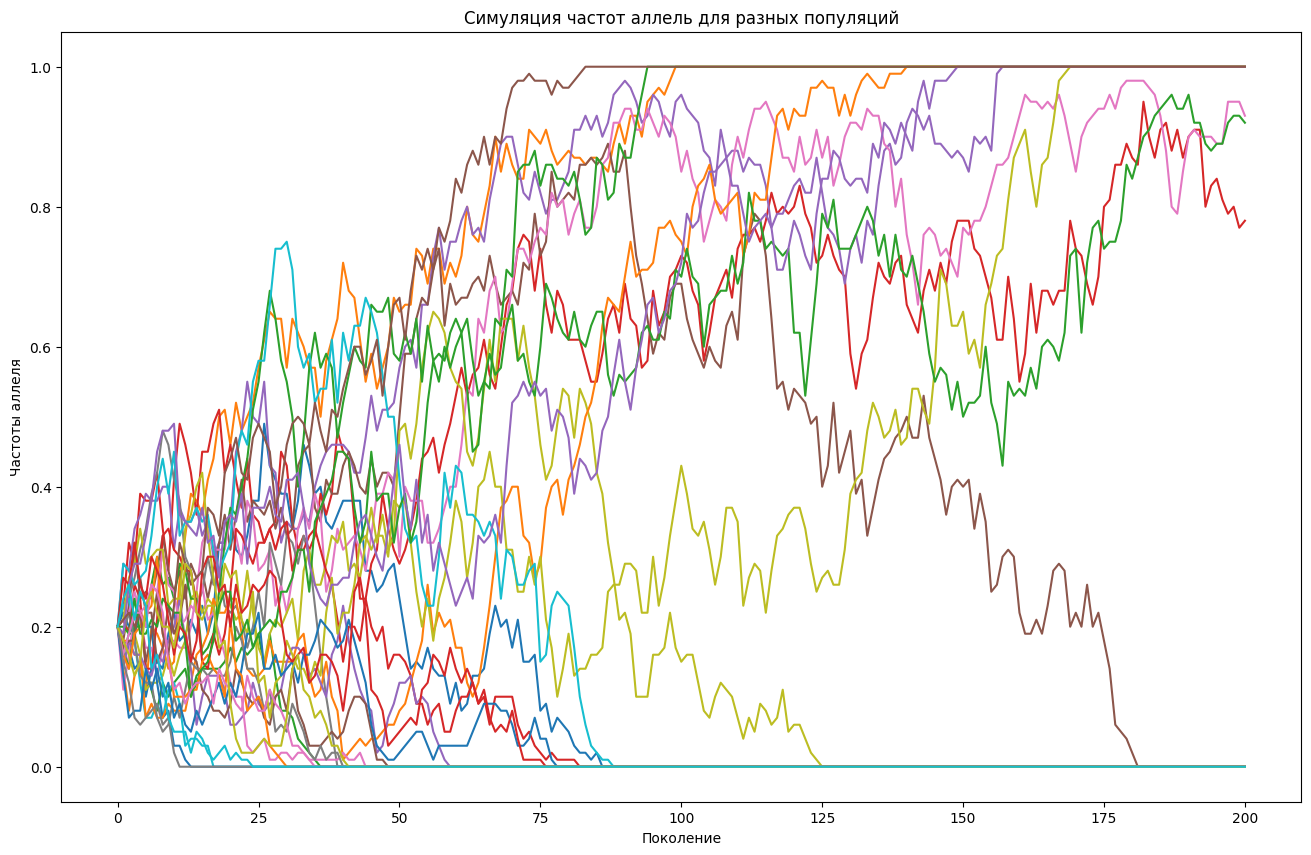

In [230]:
fig = plt.figure(figsize=(16, 10))

for gen in simulation_generations:
    plt.plot(gen)

plt.xlabel("Поколение")
plt.ylabel("Частоты аллеля")
plt.title("Симуляция частот аллель для разных популяций")
plt.show()

1. Как и говорили, те популяции, где частота аллеля ушла в 0 или 1 - больше никогда не возращается к другим значениям

2. При таком числе начального p0 большинство популяций ушли в 0 и 1.



## 2. Ожидамая гетерозитность

Выведем ожидамую гетерозитность

По формуле:

$H_t = 2 \cdot p_t (1 - p_t)$

In [231]:
excepted_genezit = 2 * simulation_generations * (1 - simulation_generations)

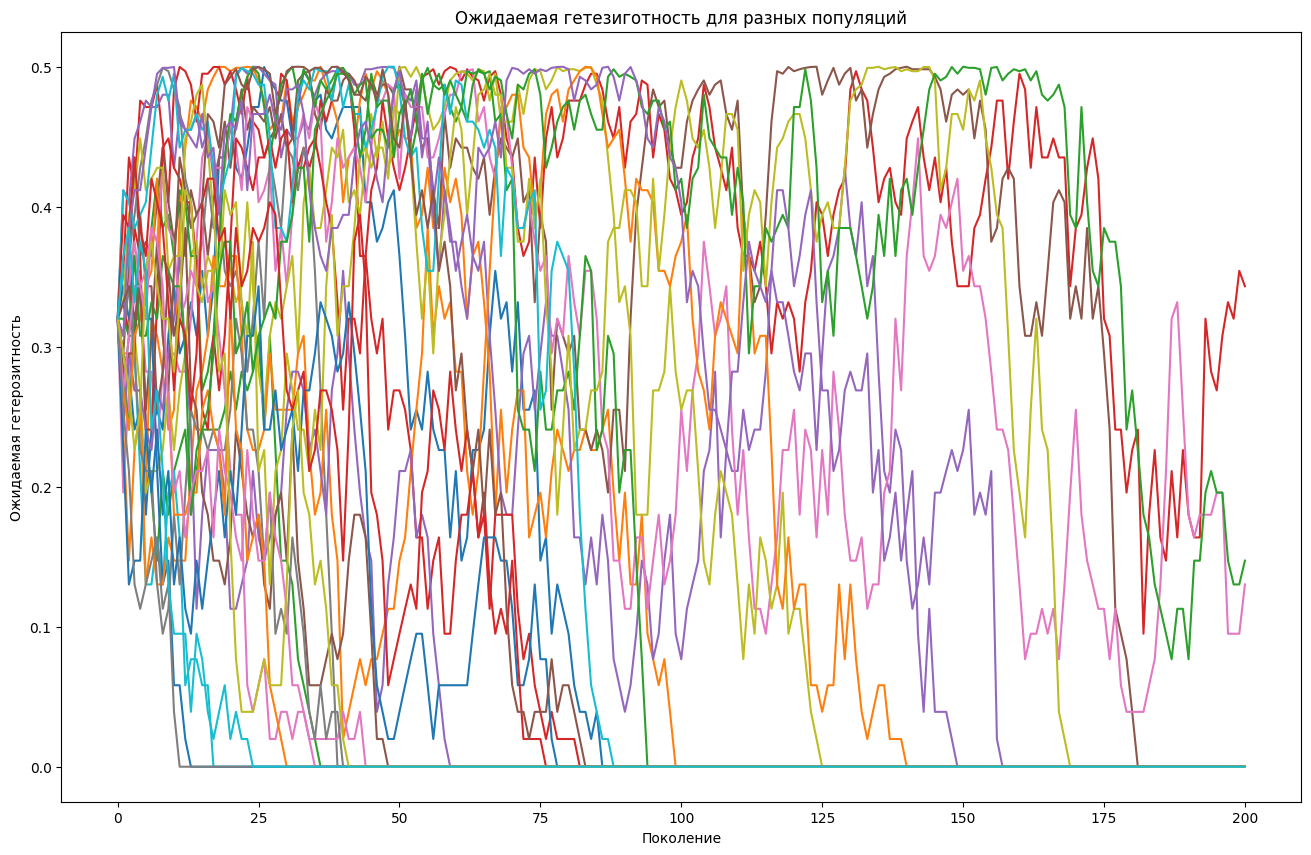

In [232]:
fig = plt.figure(figsize=(16, 10))

for ex_g in excepted_genezit:
    plt.plot(ex_g)

plt.xlabel("Поколение")
plt.ylabel("Ожидаемая гетерозитность")
plt.title("Ожидаемая гетезиготность для разных популяций")
plt.show()

Видно, что гетезиготность со временем уходит в пользу гомозиготности и на последних поколениях почти все популяции имеет гомозиготность. Это достаточно логичное следствие от того, что вероятность определенной аллели падает.

Важно проверить еще и теоретическую гетерозитогность:

Поэтому выберем среднюю гетерозитогность для поколения и теоретическую гетерозитогность

теоретическая гетерозитогность:

$H_t = H_0 (1 - \frac{1}{2N})^t$

In [233]:
mean_geterozigot = np.mean(excepted_genezit, axis=0)


H0 = 2 * p0 * (1 - p0)
teoretical_geterozigot = [H0 * (1.0 - 1.0/(2 * N)) ** t for t in range(T)]

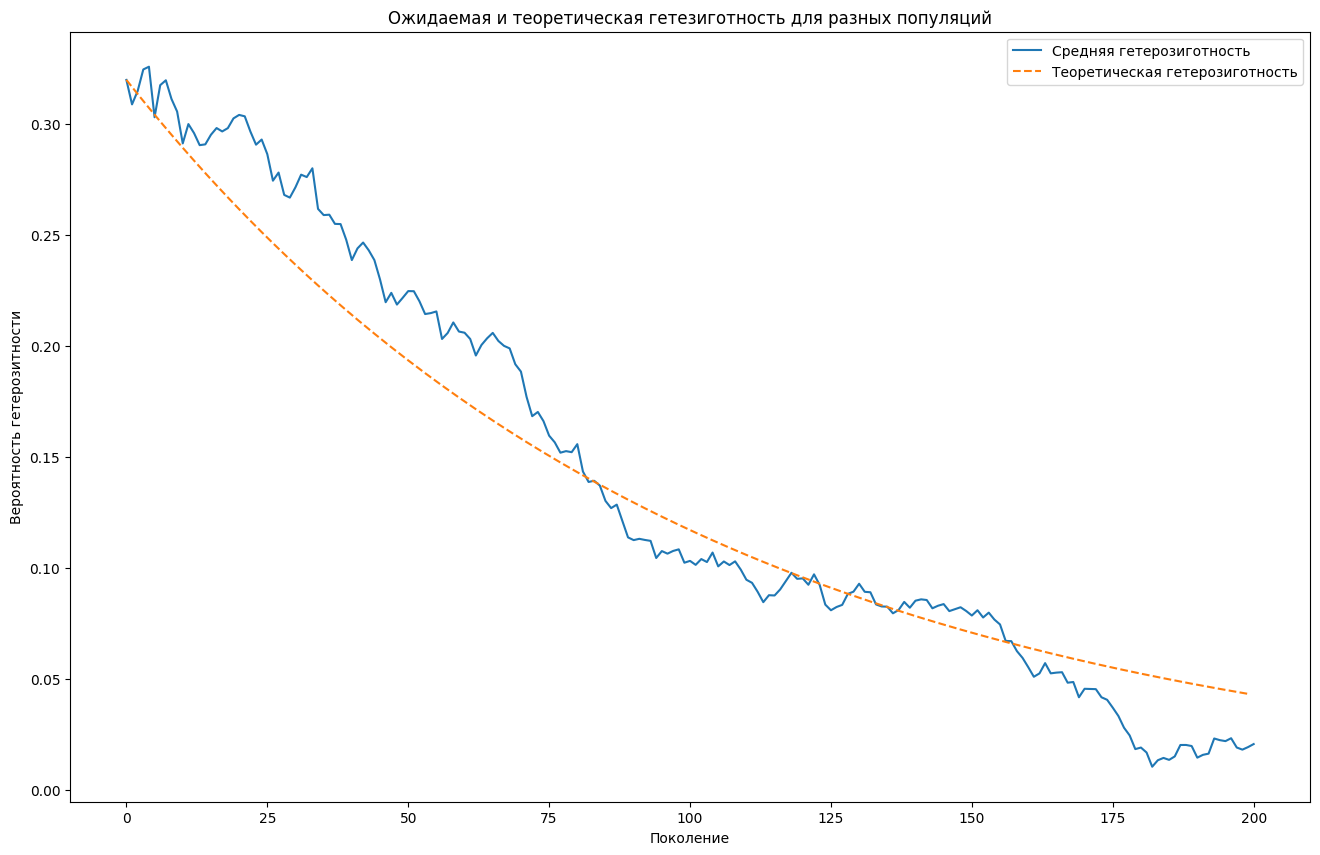

In [234]:
fig = plt.figure(figsize=(16, 10))

plt.plot(mean_geterozigot, label="Средняя гетерозиготность")
plt.plot(teoretical_geterozigot, label="Теоретическая гетерозиготность", linestyle="--")
plt.xlabel("Поколение")
plt.ylabel("Вероятность гетерозитности")
plt.title("Ожидаемая и теоретическая гетезиготность для разных популяций")
plt.legend()
plt.show()

Здесь мы не ушли стандарное отклонение величин, но все равно видно, что теоритеская кривая достаточно близка к реальной, только идет чуть медленее (что зависит от запуска)

При вероятности 0.2 для аллеля (то есть для такой популяции, где вероятность передачи аллеля 0.2 в силу числа индивидов и их аллелей) вероятность гетезиготности спустя 200 поколений почти нулевая.

Теорема о поглощении

$P[X_{\tau} = 2N | X_0 = i] = \frac{i}{2N} =\frac{p_0 2N}{2N} = p_0$

Посчитаем то, когда было первое поглощение для каждой популяции (число таких поглощений)

In [235]:
count_absr = 0
count_all = R

for r in range(R):
    for t in range(T):
        if simulation_generations[r, t] >= 1:
            count_absr += 1
            break


In [242]:
print(f"Теорема о поглощении дает результат: {p0}")
print(f"Реальный результат на симуляции: {count_absr / count_all}")

Теорема о поглощении дает результат: 0.2
Реальный результат на симуляции: 0.23333333333333334


## 3. Выполняется ли теорема? 

На каких-то запусках да, на каких-то нет. В качестве причин можно привести очень маленькое число популяций (50 штук), а также небольшое число поколений

## 4. Эффект бутылочного горлышка

Для симулярии придется немного изменить исходную функцию

In [245]:
from typing import Callable

def wright_fisher_with_din_N(N: Callable, p0, T):
    p = np.zeros(T + 1)
    p[0] = p0
    for t in range(T):
        alley_count = 2 * N(t)
        X_t_1 = np.random.binomial(alley_count, p[t])
        p[t + 1] = X_t_1 / alley_count
    return p



def run_simulation_wright_fisher_with_din_N(p0, T, R):
    def get_current_N(t):
        if 100 <= t <= 125:
            return 10
        return N

    gen = []
    for r in range(R):
        gen.append(wright_fisher_with_din_N(get_current_N, p0, T))
    return np.array(gen)


In [248]:
bottleneck_simulation = run_simulation_wright_fisher_with_din_N(p0, T, R)

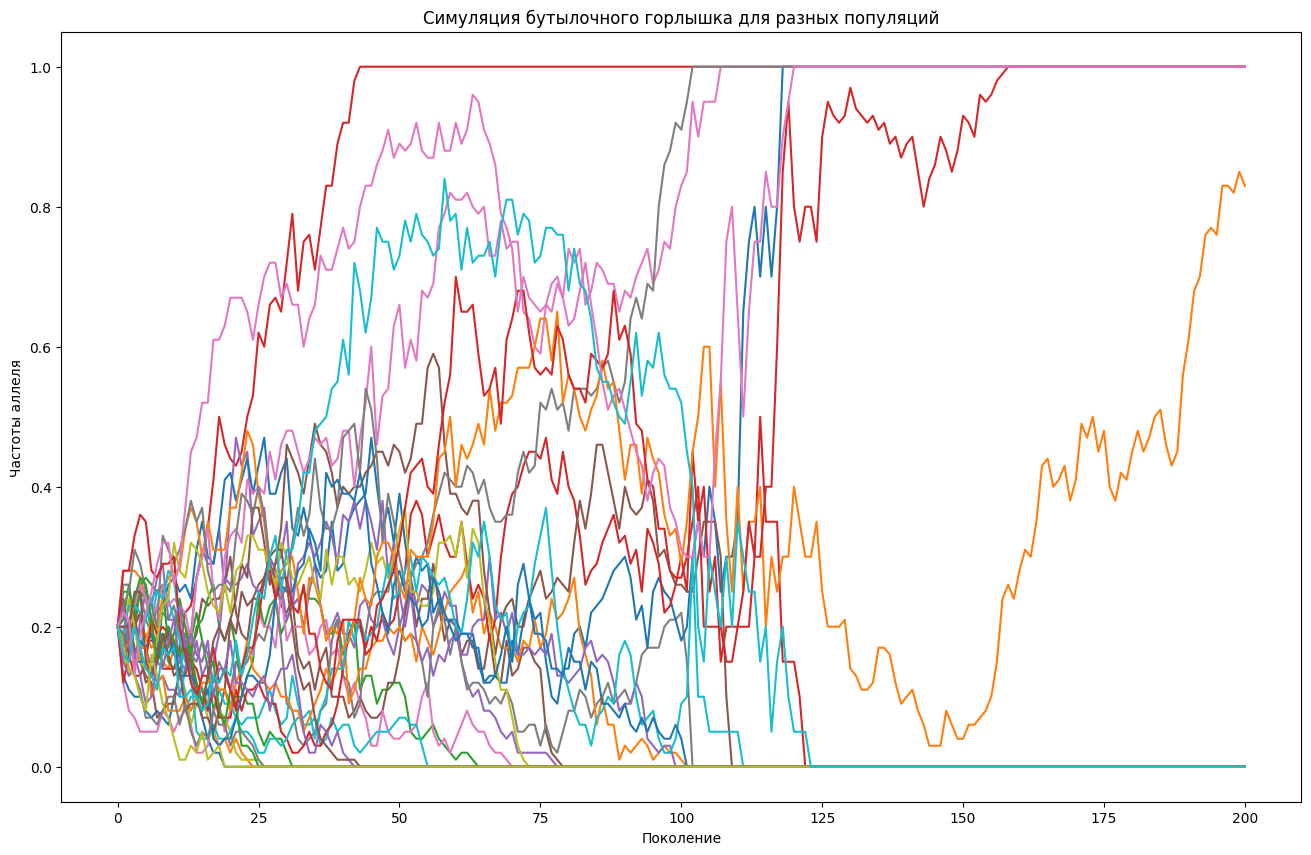

In [250]:
fig = plt.figure(figsize=(16, 10))

for gen in bottleneck_simulation:
    plt.plot(gen)

plt.xlabel("Поколение")
plt.ylabel("Частоты аллеля")
plt.title("Симуляция бутылочного горлышка для разных популяций")
plt.show()

Заметно, что в период от 100 до 125 поколения резко произошли поглощения и вырождения, а не с фиксированной величиной вероятности для алелля дошла только одна популяция

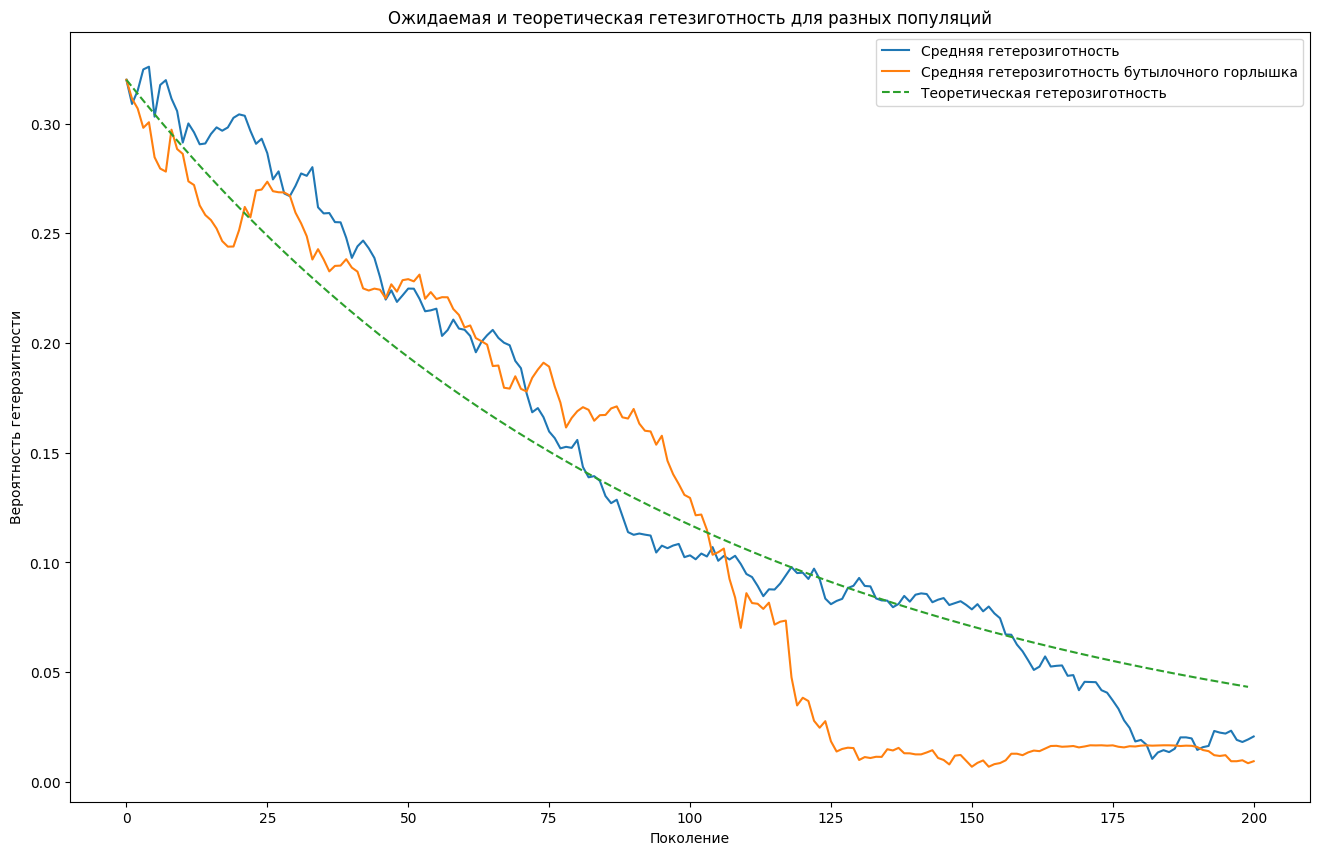

In [252]:
excepted_genezit_bottleneck = 2 * bottleneck_simulation * (1 - bottleneck_simulation)
mean_geterozigot_bottleneck = np.mean(excepted_genezit_bottleneck, axis=0)

fig = plt.figure(figsize=(16, 10))

plt.plot(mean_geterozigot, label="Средняя гетерозиготность")
plt.plot(mean_geterozigot_bottleneck, label="Средняя гетерозиготность бутылочного горлышка")
plt.plot(teoretical_geterozigot, label="Теоретическая гетерозиготность", linestyle="--")
plt.xlabel("Поколение")
plt.ylabel("Вероятность гетерозитности")
plt.title("Ожидаемая и теоретическая гетезиготность для разных популяций")
plt.legend()
plt.show()

Как мы видим по графику гетезиготности для разных поколений также присуствует резкий обвал в период от 100 до 125 поколения.


Данная кривая (bottleneck) уже не соответствует теоретическому распределению, начиная с поколения 100